# Notebook 01 — Exploratory Data Analysis
**DNSC 6330 Capstone | HMDA LAR 2024**

Goals:
- Understand raw distributions, class balance, missingness, and group base rates
- Establish a **pre-model fairness baseline** before any modeling
- Flag data quality issues for Notebook 02 (preprocessing)

## 0. Imports & Paths

In [43]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import zipfile
warnings.filterwarnings('ignore')

pd.set_option('display.max_columns', 50)
pd.set_option('display.float_format', '{:.4f}'.format)
plt.rcParams['figure.dpi'] = 120
plt.rcParams['figure.figsize'] = (10, 4)

import os

# ── All notebooks and CSVs live in the same folder ───────────────────────────
# os.getcwd() resolves to whichever folder Jupyter opened this notebook from
BASE_DIR    = os.getcwd()
FIGURES_DIR = os.path.join(BASE_DIR, 'figures')
TABLES_DIR  = os.path.join(BASE_DIR, 'tables')

os.makedirs(FIGURES_DIR, exist_ok=True)
os.makedirs(TABLES_DIR,  exist_ok=True)

print('Imports OK')
print(f'Working dir: {BASE_DIR}')
print(f'Figures dir: {FIGURES_DIR}')
print(f'Tables dir:  {TABLES_DIR}')

Imports OK
Working dir: /Users/tsotnedzeria-personal/Desktop/RML/capstone
Figures dir: /Users/tsotnedzeria-personal/Desktop/RML/capstone/figures
Tables dir:  /Users/tsotnedzeria-personal/Desktop/RML/capstone/tables


## 1. Inspect Column Names

Read only the header row (zero data loaded) to confirm exact column names before the full chunked load.

In [44]:
ZIP_PATH = os.path.join(BASE_DIR, '2024_lar.zip')

# Unzip first
with zipfile.ZipFile(ZIP_PATH, 'r') as z:
    print('Files in zip:', z.namelist())
    z.extractall(BASE_DIR)

TXT_PATH = os.path.join(BASE_DIR, '2024_lar.txt')
RAW_PATH = os.path.join(BASE_DIR, '2024_lar.csv')

# Convert .txt to .csv
pd.read_csv(TXT_PATH, sep='|').to_csv(RAW_PATH, index=False)

# nrows=0 reads only the header — no memory cost
actual_cols = pd.read_csv(RAW_PATH, nrows=0).columns.tolist()
print(f'Total columns in file: {len(actual_cols)}')
print()
for c in actual_cols:
    print(f'  {c}')

Files in zip: ['2024_lar.txt']
Total columns in file: 99

  activity_year
  lei
  derived_msa_md
  state_code
  county_code
  census_tract
  conforming_loan_limit
  derived_loan_product_type
  derived_dwelling_category
  derived_ethnicity
  derived_race
  derived_sex
  action_taken
  purchaser_type
  preapproval
  loan_type
  loan_purpose
  lien_status
  reverse_mortgage
  open_end_line_of_credit
  business_or_commercial_purpose
  loan_amount
  combined_loan_to_value_ratio
  interest_rate
  rate_spread
  hoepa_status
  total_loan_costs
  total_points_and_fees
  origination_charges
  discount_points
  lender_credits
  loan_term
  prepayment_penalty_term
  intro_rate_period
  negative_amortization
  interest_only_payment
  balloon_payment
  other_nonamortizing_features
  property_value
  construction_method
  occupancy_type
  manufactured_home_secured_property_type
  manufactured_home_land_property_interest
  total_units
  multifamily_affordable_units
  income
  debt_to_income_ratio
  ap

## 2. Chunked Load with Label Creation

The 2024 HMDA national LAR file is too large to load in one pass.
We filter and label **inside** each chunk to avoid holding the full file in memory.

Per capstone specification:
- `action_taken` values **1 and 2** → label **1** (approved)
- `action_taken` value **3** → label **0** (denied)
- All other values → **filtered out**

> **Note:** Filtering values 4–8 introduces **sample selection bias** — withdrawn/incomplete applications are non-random and may differ systematically by protected group.

In [45]:
# Columns confirmed present in 2024 HMDA LAR
# combined_loan_to_value_ratio does NOT exist in 2024 — removed from spec
# co-applicant_age uses underscore — fixed from original hyphen
# loan_to_value_ratio does NOT exist in 2024 — removed from spec
#
# Changes from original
# REMOVED: loan_to_value_ratio        (does not exist in 2024 file)
#          co-applicant_age           (hyphen typo — replaced with co_applicant_age)
#
# ADDED:   loan_term                  (15 vs 30 yr is a real risk differentiator)
#          conforming_loan_limit      (whether loan meets GSE standards, strong signal)
#          preapproval                (borrower sophistication indicator — monitor for proxy risk)
#          submission_of_application  (broker vs direct — monitor for proxy risk)
#          applicant_credit_score_type      (primary applicant credit signal)
#          co_applicant_credit_score_type   (co-applicant credit signal)
# ─────────────────────────────────────────────────────────────────────────────

DESIRED_COLS = [
    'action_taken',
    # Loan characteristics
    'loan_amount',
    'loan_type',
    'loan_purpose',
    'lien_status',
    'occupancy_type',
    'loan_term',                  # ADDED
    'conforming_loan_limit',      # ADDED
    # Applicant financials
    'income',
    'debt_to_income_ratio',
    'property_value',
    'applicant_credit_score_type',    # ADDED
    'co_applicant_credit_score_type', # ADDED
    # Application process — monitored for proxy risk
    'preapproval',                    # ADDED
    'submission_of_application',      # ADDED
    # Protected class — audit only, never trained on
    'derived_race',
    'derived_sex',
    'derived_ethnicity',
    'applicant_age',
    'co_applicant_age',               # FIXED (was co-applicant_age)
    # Geographic — analysis only, exclude from model features
    'state_code',
    'county_code',
    'census_tract',
]

# Only request columns that actually exist
KEEP_COLS = [c for c in DESIRED_COLS if c in actual_cols]
missing   = set(DESIRED_COLS) - set(KEEP_COLS)
if missing:
    print(f'Columns not found in file (skipped): {missing}')
print(f'Loading {len(KEEP_COLS)} columns.')

Loading 23 columns.


In [46]:
# ── Chunked load: filter + label inside each chunk ───────────────────────────
CHUNK_SIZE = 50_000   # reduce to 25_000 if still hitting memory limits

chunks    = []
total_raw = 0

for chunk in pd.read_csv(
    RAW_PATH,
    usecols=KEEP_COLS,
    low_memory=False,
    chunksize=CHUNK_SIZE
):
    total_raw += len(chunk)

    # Filter to action_taken 1, 2, 3 BEFORE any copy or map
    chunk = chunk[chunk['action_taken'].isin([1, 2, 3])]

    # Create label per capstone spec
    chunk['label'] = chunk['action_taken'].map({1: 1, 2: 1, 3: 0})

    # Drop action_taken — no longer needed
    chunk = chunk.drop(columns=['action_taken'])

    # Rename hyphenated column immediately
    if 'co-applicant_age' in chunk.columns:
        chunk = chunk.rename(columns={'co-applicant_age': 'co_applicant_age'})

    chunks.append(chunk)
    kept = sum(len(c) for c in chunks)
    print(f'  Processed {total_raw:,} rows | kept {kept:,}', end='\r')

df = pd.concat(chunks, ignore_index=True)
del chunks   # free memory immediately

print(f'\nDone.')
print(f'Raw rows seen:  {total_raw:,}')
print(f'Filtered rows:  {len(df):,} ({len(df)/total_raw:.1%} kept)')
print(f'Columns:        {df.shape[1]}')
print(f'\nLabel distribution:')
print(df['label'].value_counts())
print(f'\nApproval rate: {df["label"].mean():.2%}')

  Processed 12,259,119 rows | kept 8,661,748
Done.
Raw rows seen:  12,259,119
Filtered rows:  8,661,748 (70.7% kept)
Columns:        23

Label distribution:
label
1    6558285
0    2103463
Name: count, dtype: int64

Approval rate: 75.72%


In [47]:
# action_taken breakdown (reconstructed from label + note)
ACTION_LABELS = {
    1: 'Loan originated',
    2: 'Approved, not accepted',
    3: 'Application denied',
    4: 'Application withdrawn         (filtered out)',
    5: 'File closed - incomplete      (filtered out)',
    6: 'Purchased loan                (filtered out)',
    7: 'Pre-approval denied           (filtered out)',
    8: 'Pre-approval approved, not accepted (filtered out)',
}
print('action_taken mapping used:')
for k, v in ACTION_LABELS.items():
    label = {1: '→ label=1', 2: '→ label=1', 3: '→ label=0'}.get(k, '→ dropped')
    print(f'  {k}: {v:55s} {label}')

action_taken mapping used:
  1: Loan originated                                         → label=1
  2: Approved, not accepted                                  → label=1
  3: Application denied                                      → label=0
  4: Application withdrawn         (filtered out)            → dropped
  5: File closed - incomplete      (filtered out)            → dropped
  6: Purchased loan                (filtered out)            → dropped
  7: Pre-approval denied           (filtered out)            → dropped
  8: Pre-approval approved, not accepted (filtered out)      → dropped


## 3. Basic Inspection

In [48]:
print('── Data Types ──')
print(df.dtypes)
print()
print('── First 3 rows ──')
df.head(3)

── Data Types ──
state_code                         object
county_code                       float64
census_tract                       object
conforming_loan_limit              object
derived_ethnicity                  object
derived_race                       object
derived_sex                        object
preapproval                         int64
loan_type                           int64
loan_purpose                        int64
lien_status                         int64
loan_amount                         int64
loan_term                          object
property_value                     object
occupancy_type                      int64
income                            float64
debt_to_income_ratio               object
applicant_credit_score_type         int64
co_applicant_credit_score_type      int64
applicant_age                      object
co_applicant_age                   object
submission_of_application           int64
label                               int64
dtype: object

──

,state_code,county_code,census_tract,conforming_loan_limit,derived_ethnicity,derived_race,derived_sex,preapproval,loan_type,loan_purpose,lien_status,loan_amount,loan_term,property_value,occupancy_type,income,debt_to_income_ratio,applicant_credit_score_type,co_applicant_credit_score_type,applicant_age,co_applicant_age,submission_of_application,label
0,NJ,34017.0000,34017017100.0000,C,Hispanic or Latino,White,Male,2,1,31,1,635000,360,975000,3,0.0000,NaN,3,10,45-54,9999,1,1
1,NY,36059.0000,36059405900.0000,C,Not Hispanic or Latino,Asian,Male,2,2,1,1,595000,360,655000,1,140.0000,50%-60%,7,1,25-34,45-54,1,1
2,FL,12086.0000,12086001004.0000,C,Hispanic or Latino,White,Male,2,1,1,1,525000,360,555000,1,138.0000,37,3,10,35-44,9999,1,1


## 4. Class Balance

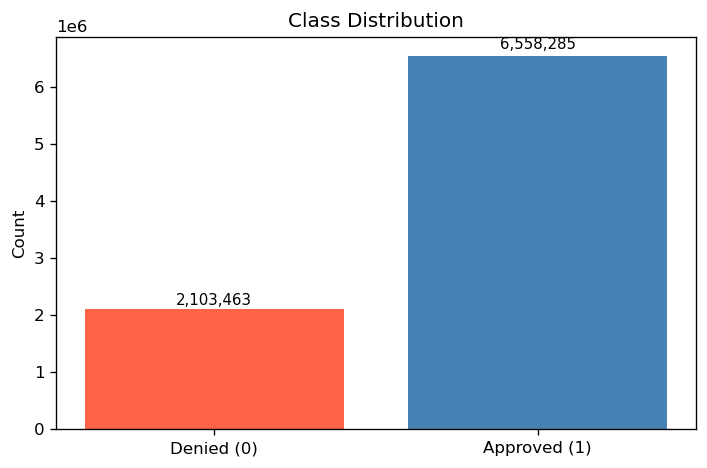

Note: values 1 and 2 are both coded as approved (label=1).
Value 2 (approved but not accepted) reflects borrower behavior, not lender decision.


In [49]:
# Visualize class balance
label_counts = df['label'].value_counts()

fig, ax = plt.subplots(figsize=(6, 4))
ax.bar(['Denied (0)', 'Approved (1)'], label_counts[[0, 1]],
       color=['tomato', 'steelblue'])
ax.set_ylabel('Count')
ax.set_title('Class Distribution')
for i, v in enumerate(label_counts[[0, 1]]):
    ax.text(i, v + v * 0.01, f'{v:,}', ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.savefig(os.path.join(FIGURES_DIR, '01_class_balance.png'))
plt.show()

print('Note: values 1 and 2 are both coded as approved (label=1).')
print('Value 2 (approved but not accepted) reflects borrower behavior, not lender decision.')

## 5. Feature Groups

In [50]:
# Define feature groups — filter to columns that exist in this load
NUMERIC_FEATURES = [
    'loan_amount', 'income', 'property_value',
    'debt_to_income_ratio', 'loan_to_value_ratio',
    'loan_term',                        # ADDED
]
CATEGORICAL_FEATURES = [
    'loan_type', 'loan_purpose', 'occupancy_type', 'lien_status',
    'conforming_loan_limit',            # ADDED — encoded as C/NC/U in HMDA
    'preapproval',                      # ADDED — monitor for proxy risk
    'submission_of_application',        # ADDED — monitor for proxy risk
    'applicant_credit_score_type',      # ADDED
    'co_applicant_credit_score_type',   # ADDED
]
PROTECTED_FEATURES = [
    'derived_race', 'derived_sex', 'derived_ethnicity',
    'applicant_age', 'co_applicant_age',
]
GEO_FEATURES = ['state_code', 'county_code', 'census_tract']

# Filter each group to confirmed-present columns
NUMERIC_FEATURES     = [c for c in NUMERIC_FEATURES     if c in df.columns]
CATEGORICAL_FEATURES = [c for c in CATEGORICAL_FEATURES if c in df.columns]
PROTECTED_FEATURES   = [c for c in PROTECTED_FEATURES   if c in df.columns]
GEO_FEATURES         = [c for c in GEO_FEATURES         if c in df.columns]

print(f'Numeric features ({len(NUMERIC_FEATURES)}):     {NUMERIC_FEATURES}')
print(f'Categorical features ({len(CATEGORICAL_FEATURES)}): {CATEGORICAL_FEATURES}')
print(f'Protected features ({len(PROTECTED_FEATURES)}):   {PROTECTED_FEATURES}')
print(f'Geographic features ({len(GEO_FEATURES)}):   {GEO_FEATURES}')

Numeric features (5):     ['loan_amount', 'income', 'property_value', 'debt_to_income_ratio', 'loan_term']
Categorical features (9): ['loan_type', 'loan_purpose', 'occupancy_type', 'lien_status', 'conforming_loan_limit', 'preapproval', 'submission_of_application', 'applicant_credit_score_type', 'co_applicant_credit_score_type']
Protected features (5):   ['derived_race', 'derived_sex', 'derived_ethnicity', 'applicant_age', 'co_applicant_age']
Geographic features (3):   ['state_code', 'county_code', 'census_tract']


## 6. Numeric Feature Distributions

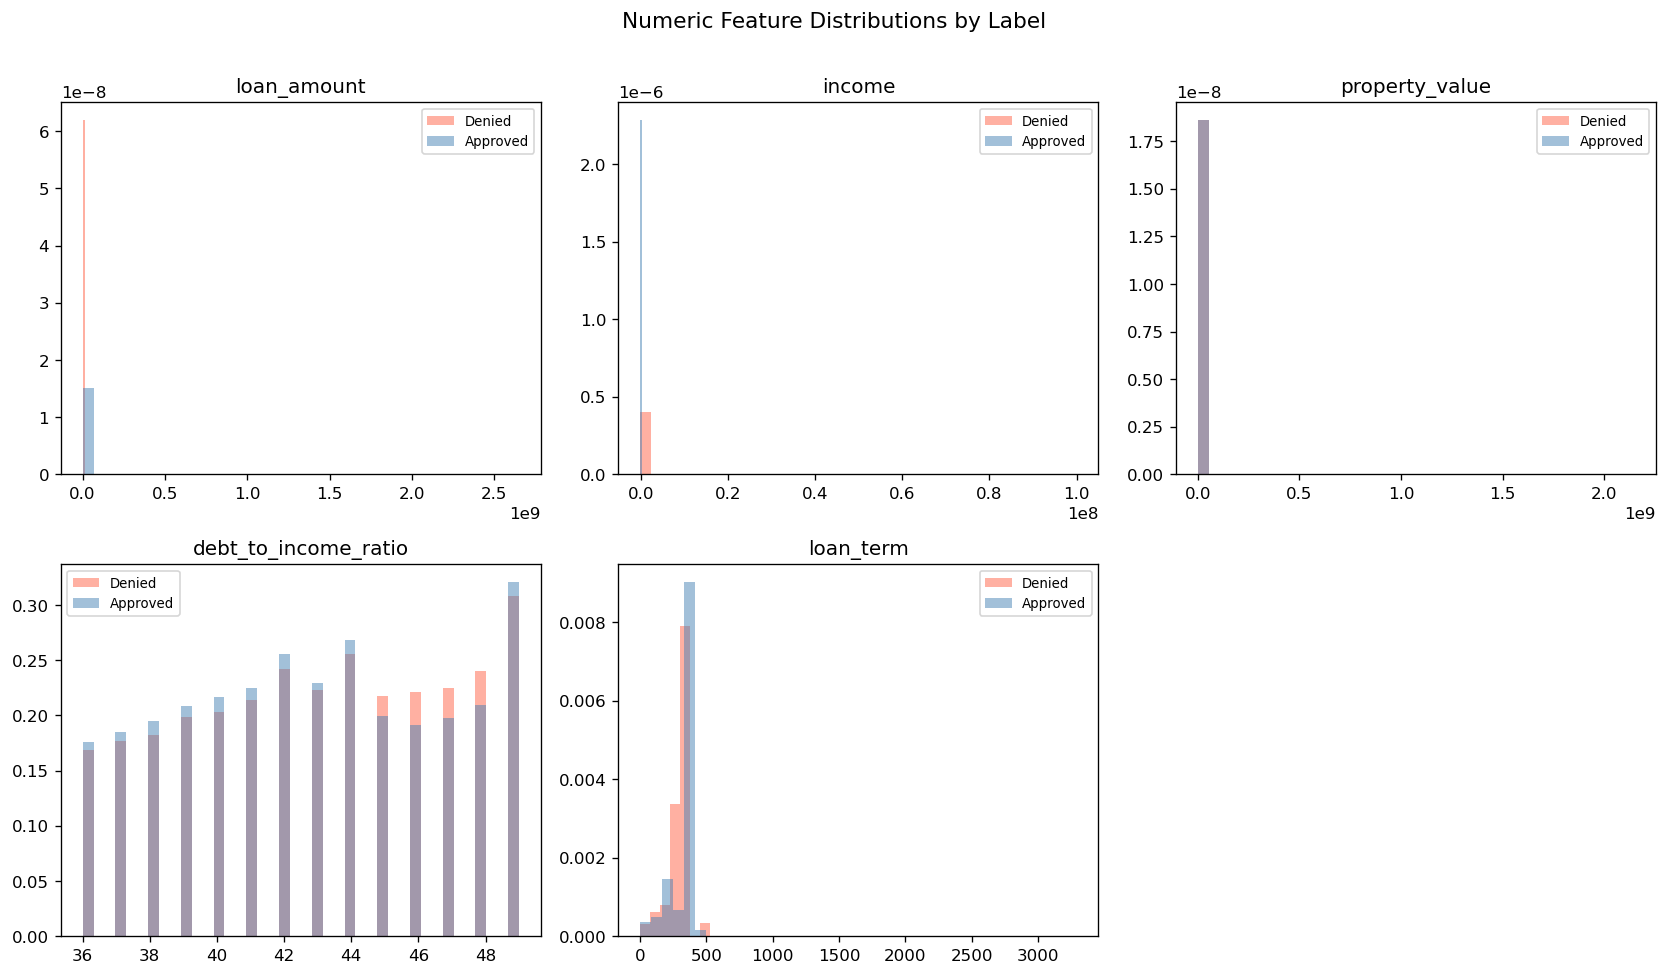

In [51]:
if NUMERIC_FEATURES:
    n_cols = min(3, len(NUMERIC_FEATURES))
    n_rows = int(np.ceil(len(NUMERIC_FEATURES) / n_cols))
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(14, 4 * n_rows))
    axes = axes.flatten() if hasattr(axes, 'flatten') else [axes]

    for i, col in enumerate(NUMERIC_FEATURES):
        plot_col = pd.to_numeric(df[col], errors='coerce')
        for label, color, name in [(0, 'tomato', 'Denied'), (1, 'steelblue', 'Approved')]:
            axes[i].hist(
                plot_col[df['label'] == label].dropna(),
                bins=40, alpha=0.5, color=color, label=name, density=True
            )
        axes[i].set_title(col)
        axes[i].legend(fontsize=8)

    for j in range(i + 1, len(axes)):
        axes[j].set_visible(False)

    fig.suptitle('Numeric Feature Distributions by Label', y=1.01, fontsize=13)
    plt.tight_layout()
    plt.savefig(os.path.join(FIGURES_DIR, '01_numeric_distributions.png'), bbox_inches='tight')
    plt.show()

## 7. Categorical Feature Distributions

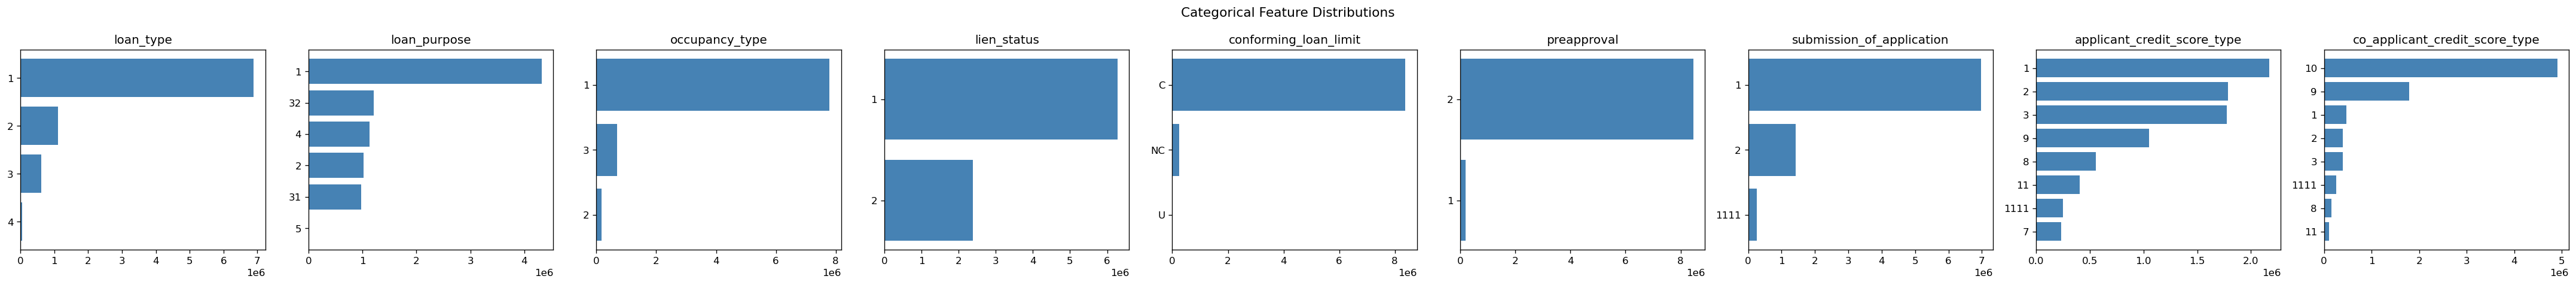

In [52]:
if CATEGORICAL_FEATURES:
    fig, axes = plt.subplots(1, len(CATEGORICAL_FEATURES),
                             figsize=(4 * len(CATEGORICAL_FEATURES), 4))
    if len(CATEGORICAL_FEATURES) == 1:
        axes = [axes]

    for i, col in enumerate(CATEGORICAL_FEATURES):
        top_vals = df[col].value_counts().head(8)
        axes[i].barh(top_vals.index.astype(str), top_vals.values, color='steelblue')
        axes[i].set_title(col)
        axes[i].invert_yaxis()

    fig.suptitle('Categorical Feature Distributions', fontsize=13)
    plt.tight_layout()
    plt.savefig(os.path.join(FIGURES_DIR, '01_categorical_distributions.png'), bbox_inches='tight')
    plt.show()

## 8. Missingness

In [53]:
# HMDA uses 'Exempt' and special codes as missing
HMDA_NA_VALUES = ['Exempt', 'NA', '', ' ', 'N/A', 'nan']

df_na = df.replace(HMDA_NA_VALUES, np.nan)

missing = (
    df_na.isnull().sum()
    .reset_index()
    .rename(columns={'index': 'column', 0: 'n_missing'})
)
missing['pct_missing'] = missing['n_missing'] / len(df_na)
missing = missing[missing['n_missing'] > 0].sort_values('pct_missing', ascending=False)

print(f'Columns with missing values: {len(missing)} / {df_na.shape[1]}')
print(missing.to_string(index=False))

Columns with missing values: 8 / 23
               column  n_missing  pct_missing
 debt_to_income_ratio     941914       0.1087
       property_value     569749       0.0658
               income     545497       0.0630
            loan_term     412133       0.0476
         census_tract     119041       0.0137
          county_code      87858       0.0101
           state_code      45496       0.0053
conforming_loan_limit      37792       0.0044


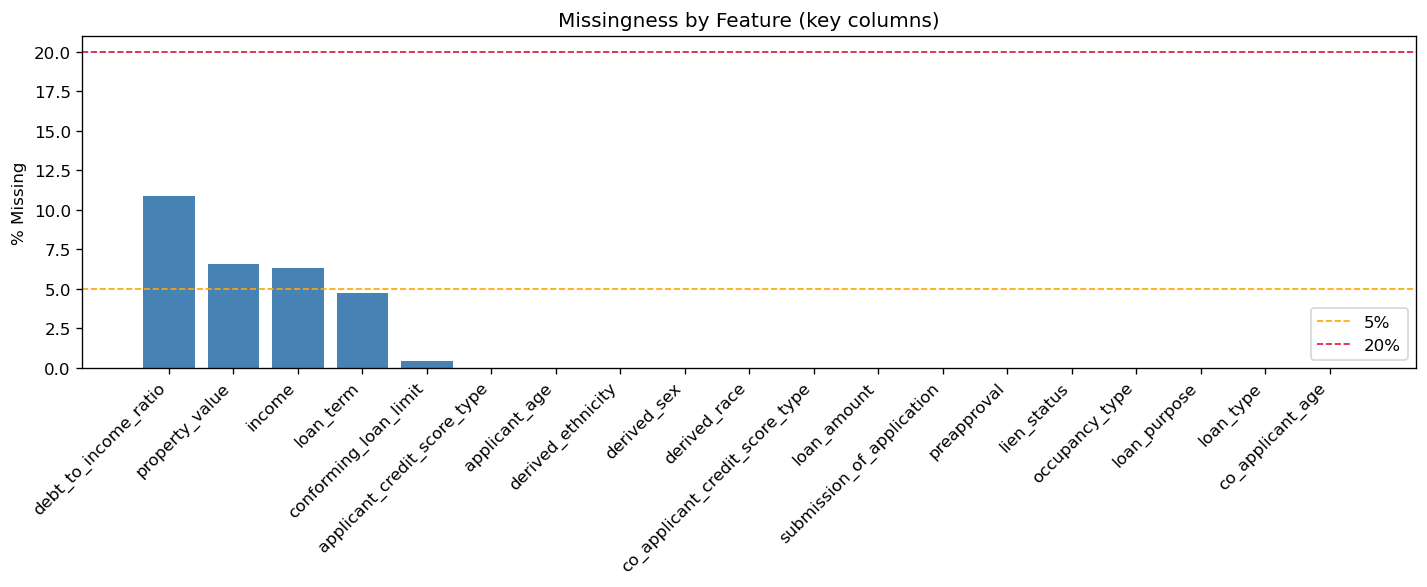

In [54]:
# Missingness bar chart for key columns only
key_cols = NUMERIC_FEATURES + CATEGORICAL_FEATURES + PROTECTED_FEATURES
key_cols = [c for c in key_cols if c in df_na.columns]

miss_pct = df_na[key_cols].isnull().mean().sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(12, 5))
ax.bar(miss_pct.index, miss_pct.values * 100, color='steelblue')
ax.axhline(5,  color='orange', linestyle='--', linewidth=1, label='5%')
ax.axhline(20, color='crimson', linestyle='--', linewidth=1, label='20%')
ax.set_ylabel('% Missing')
ax.set_title('Missingness by Feature (key columns)')
ax.set_xticklabels(miss_pct.index, rotation=45, ha='right')
ax.legend()
plt.tight_layout()
plt.savefig(os.path.join(FIGURES_DIR, '01_missingness.png'))
plt.show()

## 9. Protected Class Base Rates — Pre-Model Fairness Baseline

> This is the **pre-model fairness baseline** — approval rates by group before any model is fitted.
> Apply the **EEOC 80% rule**: any group whose approval rate is less than 80% of the maximum group's rate is flagged.

In [55]:
def approval_rate_table(df, group_col, label_col='label', min_n=50):
    """
    Compute approval rate, count, and 80% rule AIR per group.
    """
    df_clean = df.replace(HMDA_NA_VALUES, np.nan).dropna(subset=[group_col])
    stats = (
        df_clean.groupby(group_col)[label_col]
        .agg(['mean', 'count'])
        .rename(columns={'mean': 'approval_rate', 'count': 'n'})
    )
    stats = stats[stats['n'] >= min_n]
    max_rate = stats['approval_rate'].max()
    stats['AIR']        = (stats['approval_rate'] / max_rate).round(4)
    stats['fails_80pct'] = stats['AIR'] < 0.80
    return stats.sort_values('approval_rate', ascending=False)


for col in PROTECTED_FEATURES:
    print(f'\n── Approval rates by {col} ──')
    tbl = approval_rate_table(df, col)
    print(tbl.to_string())
    flagged = tbl[tbl['fails_80pct']]
    if not flagged.empty:
        print(f'  ⚠ 80% rule FAILS for: {flagged.index.tolist()}')
    else:
        print('  ✓ 80% rule holds for all groups')


── Approval rates by derived_race ──
                                           approval_rate        n    AIR  fails_80pct
derived_race                                                                         
Joint                                             0.8046   189064 1.0000        False
Asian                                             0.7873   524984 0.9785        False
White                                             0.7819  5550893 0.9718        False
Race Not Available                                0.7224  1526032 0.8978        False
Black or African American                         0.6334   762460 0.7873         True
American Indian or Alaska Native                  0.6297    63158 0.7826         True
2 or more minority races                          0.6197    21855 0.7702         True
Native Hawaiian or Other Pacific Islander         0.6130    21117 0.7619         True
Free Form Text Only                               0.4105     2185 0.5102         True
  ⚠ 80% rule FAI

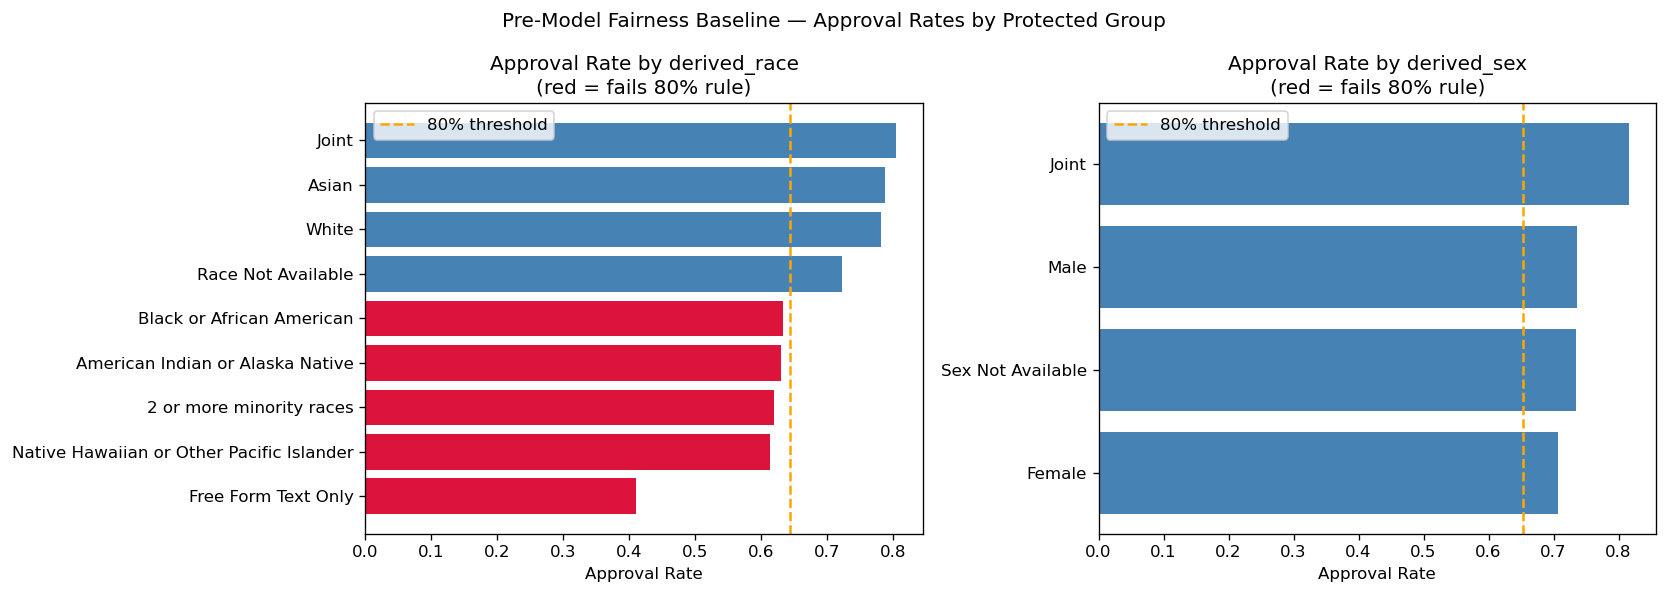

In [56]:
# Visualize approval rates by race and sex
plot_cols = [c for c in ['derived_race', 'derived_sex'] if c in PROTECTED_FEATURES]

if plot_cols:
    fig, axes = plt.subplots(1, len(plot_cols), figsize=(7 * len(plot_cols), 5))
    if len(plot_cols) == 1:
        axes = [axes]

    for i, col in enumerate(plot_cols):
        tbl = approval_rate_table(df, col).reset_index()
        colors = ['crimson' if f else 'steelblue' for f in tbl['fails_80pct']]
        axes[i].barh(tbl[col].astype(str), tbl['approval_rate'], color=colors)
        axes[i].axvline(
            tbl['approval_rate'].max() * 0.80,
            color='orange', linestyle='--', linewidth=1.5, label='80% threshold'
        )
        axes[i].set_xlabel('Approval Rate')
        axes[i].set_title(f'Approval Rate by {col}\n(red = fails 80% rule)')
        axes[i].legend()
        axes[i].invert_yaxis()

    plt.suptitle('Pre-Model Fairness Baseline — Approval Rates by Protected Group', fontsize=12)
    plt.tight_layout()
    plt.savefig(os.path.join(FIGURES_DIR, '01_premodel_fairness_baseline.png'))
    plt.show()

## 10. Numeric Summary by Label

In [57]:
key_numeric = [c for c in NUMERIC_FEATURES if c in df.columns]
numeric_parsed = df[key_numeric + ['label']].copy()
for col in key_numeric:
    numeric_parsed[col] = pd.to_numeric(numeric_parsed[col], errors='coerce')

print('── Numeric Summary by Label ──')
print(numeric_parsed.groupby('label').describe().T)

── Numeric Summary by Label ──
label                                    0               1
loan_amount          count    2103463.0000    6558285.0000
                     mean      211404.9522     325750.1672
                     std      1460548.4183    2063069.4934
                     min         5000.0000       5000.0000
                     25%        65000.0000     105000.0000
                     50%       125000.0000     235000.0000
                     75%       255000.0000     385000.0000
                     max    645005000.0000 2650005000.0000
income               count    2012655.0000    6103596.0000
                     mean         227.1945        174.9043
                     std        75127.8065      11488.8245
                     min      -155317.0000     -90000.0000
                     25%           49.0000         74.0000
                     50%           80.0000        113.0000
                     75%          129.0000        175.0000
                     max 

## 11. Save Filtered DataFrame for Notebook 02

In [58]:
# CSV fallback — no type conversion issues, works everywhere
save_path = os.path.join(BASE_DIR, 'df_filtered.csv')
df.to_csv(save_path, index=False)
print(f'Saved → {save_path} | Shape: {df.shape}')

Saved → /Users/tsotnedzeria-personal/Desktop/RML/capstone/df_filtered.csv | Shape: (8661748, 23)
